<a href="https://colab.research.google.com/github/bwecworkshop-dot/eventapplication/blob/main/stock_priceg_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving stock_data.csv to stock_data.csv
User uploaded file "stock_data.csv" with length 37728 bytes


In [36]:
import pandas as pd

# Load dataset
df = pd.read_csv('stock_data.csv')

# View first rows
print(df.head())

   Unnamed: 0     Stock_1     Stock_2    Stock_3     Stock_4     Stock_5
0  2020-01-01  101.764052  100.160928  99.494642   99.909756  101.761266
1  2020-01-02  102.171269   99.969968  98.682973  100.640755  102.528643
2  2020-01-03  103.171258   99.575237  98.182139  100.574847  101.887811
3  2020-01-04  105.483215   99.308641  97.149381  100.925017  101.490049
4  2020-01-05  107.453175   98.188428  99.575396  101.594411  101.604283


In [38]:
# Shape of dataset
print("Shape:", df.shape)


Shape: (365, 6)


In [39]:
# Data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    object 
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), object(1)
memory usage: 17.2+ KB
None


In [40]:
# Statistical summary
print(df.describe())

          Stock_1     Stock_2     Stock_3     Stock_4     Stock_5
count  365.000000  365.000000  365.000000  365.000000  365.000000
mean   107.772577   81.105216   94.519502  117.407560  106.866865
std      7.398296   11.435212    6.519213    6.778527    3.760968
min     91.474442   62.414219   81.111434   99.909756   99.833309
25%    101.603117   69.328263   89.788068  112.209912  103.927072
50%    107.421299   84.283525   94.495546  117.788079  106.411328
75%    113.741728   91.548859   99.919465  123.132365  109.178007
max    121.901773  100.160928  107.588373  129.911386  116.243803


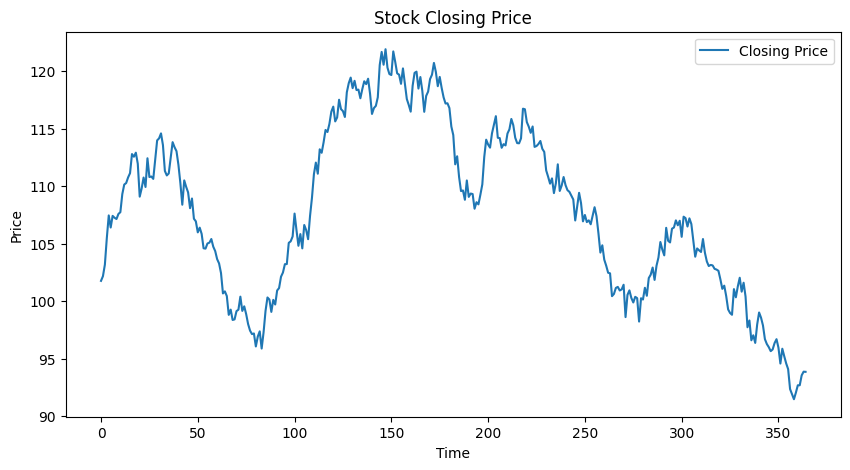

In [43]:
import matplotlib.pyplot as plt

# Plot closing price
plt.figure(figsize=(10,5))
plt.plot(df['Stock_1'], label='Closing Price')
plt.title('Stock Closing Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

In [46]:
# Check missing values
print(df.isnull().sum())

# Fill missing values (if any)
df.fillna(method='ffill', inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

Unnamed: 0    0
Stock_1       0
Stock_2       0
Stock_3       0
Stock_4       0
Stock_5       0
dtype: int64


/tmp/ipykernel_6736/3580660302.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [44]:
# Check missing values
print(df.isnull().sum())


Unnamed: 0    0
Stock_1       0
Stock_2       0
Stock_3       0
Stock_4       0
Stock_5       0
dtype: int64


In [49]:
df.fillna(method='ffill',inplace=False)

/tmp/ipykernel_6736/2244118238.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=False)


,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283
...,...,...,...,...,...,...
360,2020-12-26,92.684784,63.408103,98.288992,117.788079,102.995720
361,2020-12-27,92.688279,62.816639,98.061845,116.605106,102.718260
362,2020-12-28,93.551993,63.597651,96.454800,115.441164,103.566068
363,2020-12-29,93.870037,64.114492,95.747485,113.856107,103.257107


In [47]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [52]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Scale 'Stock_1' column (assuming 'Stock_1' is the column to scale)
df['Stock_1_scaled'] = scaler.fit_transform(df[['Stock_1']])


In [55]:
df['lag1'] = df['Stock_1'].shift(1)
df['lag2'] = df['Stock_1'].shift(2)

In [58]:
# Drop NaN after shifting
df.dropna(inplace=True)

# Select features
X = df[['lag1', 'lag2']]
y = df['Stock_1']

In [59]:
# Select features
X = df[['lag1', 'lag2']]
y = df['Stock_1']

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model
model = LinearRegression()

# Train
model.fit(X_train, y_train)

LinearRegression()

In [61]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.9524205503085803
R2 Score: 0.9568539296662929


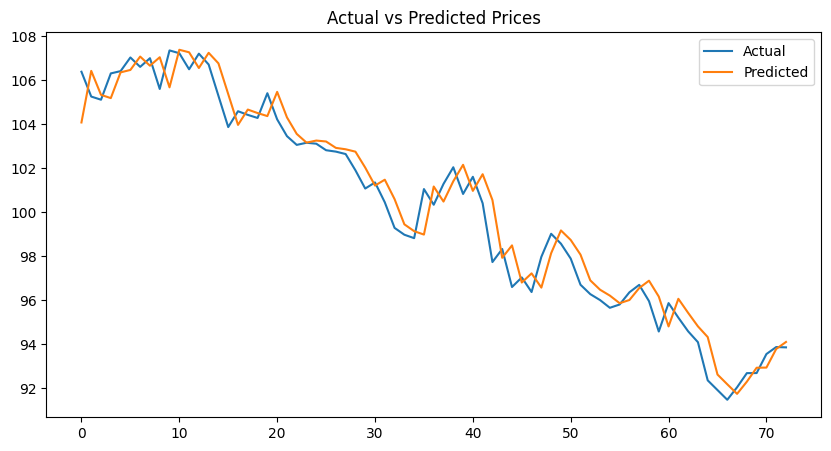

In [62]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

In [63]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RF R2 Score:", r2_score(y_test, rf_pred))

RF R2 Score: 0.746771918279312


In [70]:
# Install Streamlit
!pip install streamlit -q

In [71]:
# Save the trained Linear Regression model using pickle
import pickle

with open('model.pkl', 'wb') as file:
    pickle.dump(model, file)

In [77]:
import streamlit as st
import numpy as np
import pickle

# The streamlit app content
streamlit_app_code = '''
import streamlit as st
import numpy as np
import pickle

# Load model
model = pickle.load(open('model.pkl', 'rb'))

st.title("Stock Price Predictor")

lag1 = st.number_input("Previous Day Price")
lag2 = st.number_input("2 Days Before Price")

if st.button("Predict"):
    prediction = model.predict(np.array([[lag1, lag2]]))
    st.write("Predicted Price:", prediction[0])
'''

# Write the Streamlit app code to a file named app.py
with open('app.py', 'w') as f:
    f.write(streamlit_app_code)

# Run the Streamlit app
!streamlit run app.py &>/dev/null&  # This runs Streamlit in the background

# Display the public URL to access the Streamlit app
!npx localtunnel --port 8501

⠙⠹⠸^C


In [75]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))